# Credit Risk — EDA e Baseline

Dataset: [Give Me Some Credit (Kaggle)](https://www.kaggle.com/c/GiveMeSomeCredit)

**Target:** `SeriousDlqin2yrs` — 1 se a pessoa teve atraso de 90+ dias nos 2 anos seguintes (default).

**Objetivo deste notebook:** entender os dados, aplicar limpeza justificada e estabelecer um baseline
com regressão logística avaliado por AUC-ROC. Este AUC é o marco que os próximos modelos devem bater.

In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 1. Leitura dos dados

Caminho relativo ao notebook (funciona em qualquer máquina, ao contrário de `C:\\Users\\...`).

In [86]:
df = pd.read_csv("../data/raw/cs-training.csv", index_col=0)
df.shape

(150000, 11)

In [87]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Análise exploratória

### 2.1 Target — desbalanceamento

In [88]:
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nTaxa de default: {df['SeriousDlqin2yrs'].mean():.2%}")

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Taxa de default: 6.68%


### 2.2 Missing values

`MonthlyIncome` (~20%) e `NumberOfDependents` (~2,6%). Perguntas a responder:
1. O missing é informativo? (taxa de default difere entre quem declarou e quem não declarou renda?)
2. Os dois missings se sobrepõem? (se sim, uma flag só basta)

In [89]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [90]:
# Taxa de default por grupo: renda declarada vs. não declarada
df.groupby(df['MonthlyIncome'].isna())['SeriousDlqin2yrs'].agg(['mean', 'count'])

,mean,count
MonthlyIncome,,
False,0.069486,120269
True,0.056137,29731


In [91]:
# Sobreposição dos missings: dependentes faltante é subconjunto de renda faltante?
pd.crosstab(df['MonthlyIncome'].isna(), df['NumberOfDependents'].isna())

NumberOfDependents,False,True
MonthlyIncome,,
False,120269,0
True,25807,3924


### 2.3 Anomalias de valor

Três suspeitas a quantificar antes de tratar:
- `age`: valor mínimo impossível?
- `RevolvingUtilizationOfUnsecuredLines`: é uma proporção — deveria viver entre 0 e ~1
- Colunas de atraso: valores 96/98 são códigos sentinela, não contagens reais

In [92]:
cols_atraso = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

print(f"Idade mínima: {df['age'].min()}  (linhas com age < 18: {(df['age'] < 18).sum()})")
print("\nQuantis de RevolvingUtilization:")
print(df['RevolvingUtilizationOfUnsecuredLines'].quantile([0.5, 0.95, 0.99, 0.999, 1.0]))
print("\nValores > 20 nas colunas de atraso (sentinelas 96/98):")
for c in cols_atraso:
    print(f"  {c}: {df[df[c] > 20][c].value_counts().to_dict()}")

Idade mínima: 0  (linhas com age < 18: 1)

Quantis de RevolvingUtilization:
0.500        0.154181
0.950        1.000000
0.990        1.092956
0.999     1571.006000
1.000    50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Valores > 20 nas colunas de atraso (sentinelas 96/98):
  NumberOfTime30-59DaysPastDueNotWorse: {98: 264, 96: 5}
  NumberOfTime60-89DaysPastDueNotWorse: {98: 264, 96: 5}
  NumberOfTimes90DaysLate: {98: 264, 96: 5}


In [93]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Regras de limpeza de domínio (constantes fixas, sem estatística aprendida -> sem leakage)."""
    df = df[df['age'] >= 18].copy()
    # 96/98 são códigos sentinela; o máximo real de atrasos em 2 anos fica abaixo de 20
    for c in cols_atraso:
        df[c] = df[c].clip(upper=20)
    # Utilização é proporção; >10 (1000% do limite) é erro de dado. Cap conservador.
    df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=10)
    return df

n_antes = len(df)
df = clean(df)
print(f"Linhas removidas: {n_antes - len(df)}")

Linhas removidas: 1


### 2.4 Features vs. target

Objetivo: sair daqui sabendo quais são as 3 features mais fortes (sanity check para o SHAP depois).

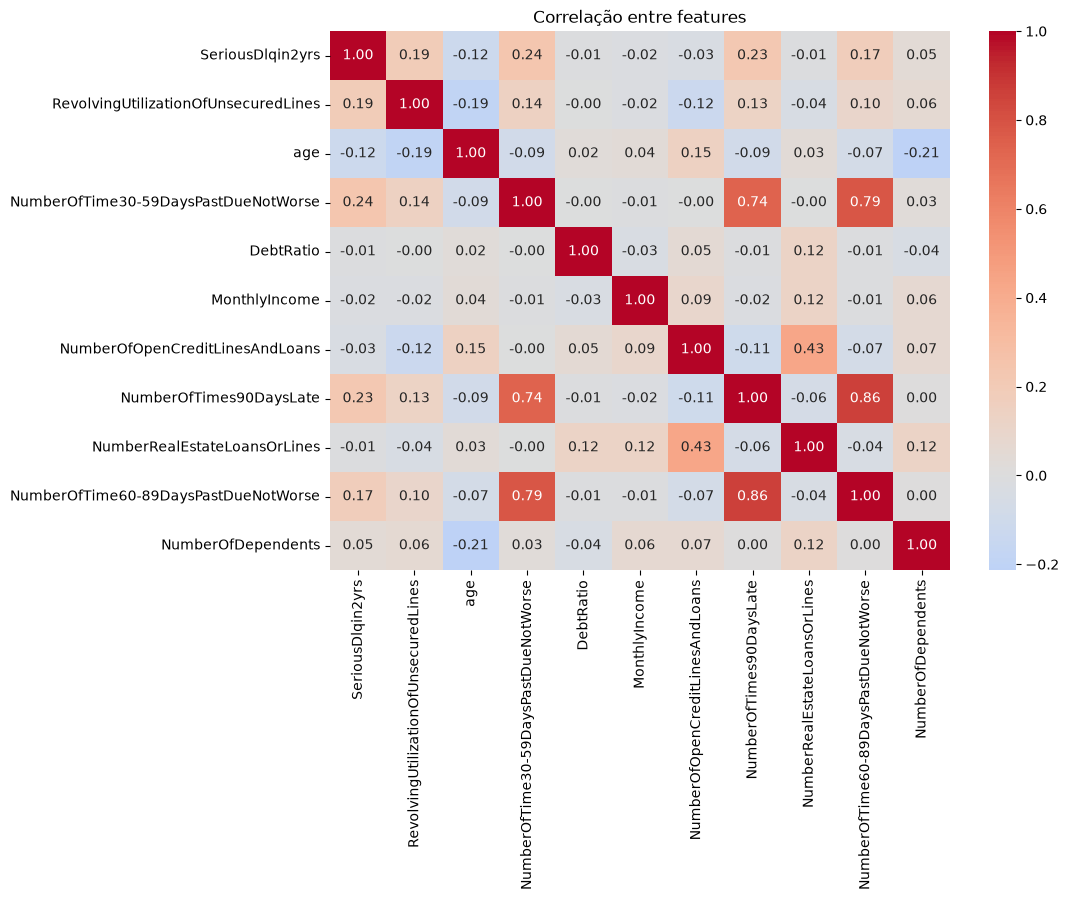

In [94]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre features')
plt.show()

## 3. Split

Split **antes** de qualquer estatística aprendida (mediana, scaler). A flag `declarou_renda` é
regra fixa (não aprende nada dos dados), então pode ser criada antes.

In [95]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Flag antes da imputacao: depois que a mediana preenche, a informacao se perde
X['declarou_renda'] = X['MonthlyIncome'].notna().astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((119999, 11), (30000, 11))

## 4. Modelagem — baseline

Tudo dentro de um `Pipeline`: imputação → scaler → modelo. Isso garante que:
- o `fit` aprende medianas/escala **só no treino** (sem leakage);
- o mesmo pré-processamento é aplicado automaticamente no teste (e, depois, na API);
- o objeto inteiro é serializável para o MLflow (Fase 2).

`class_weight='balanced'` compensa o desbalanceamento; a métrica é **AUC-ROC** sobre
`predict_proba` (em crédito entregamos probabilidade, não classe).

In [96]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # atinge MonthlyIncome e NumberOfDependents; no-op nas demais
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000)),
])

In [97]:
# Validacao cruzada no treino: estimativa estavel do AUC (media +/- desvio)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"AUC (CV 5-fold): {scores.mean():.4f} +/- {scores.std():.4f}")

AUC (CV 5-fold): 0.8517 +/- 0.0051


In [98]:
# Avaliacao final no teste (so depois que o CV estabilizou as decisoes)
pipe.fit(X_train, y_train)
proba_test = pipe.predict_proba(X_test)[:, 1]
print(f"AUC (teste): {roc_auc_score(y_test, proba_test):.4f}")

AUC (teste): 0.8576


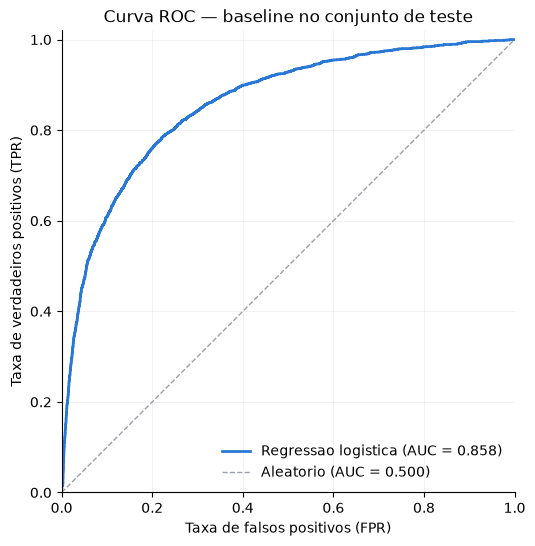

In [99]:
# Curva ROC: cada ponto e um threshold; a curva mostra o trade-off FPR x TPR
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, proba_test)
auc_test = roc_auc_score(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='#2a78d6', linewidth=2,
        label=f'Regressao logistica (AUC = {auc_test:.3f})')
ax.plot([0, 1], [0, 1], color='#9aa0a6', linewidth=1, linestyle='--',
        label='Aleatorio (AUC = 0.500)')

ax.set_xlabel('Taxa de falsos positivos (FPR)')
ax.set_ylabel('Taxa de verdadeiros positivos (TPR)')
ax.set_title('Curva ROC — baseline no conjunto de teste')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_aspect('equal')
ax.legend(loc='lower right', frameon=False)
ax.grid(alpha=0.25, linewidth=0.5)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

## Conclusões e próximos passos

Próximos passos:
- [ ] Curva de calibração (`sklearn.calibration`)
- [ ] Graduar `clean()` e o pipeline para `src/credit_risk/`
- [ ] MLflow (Fase 2)